# 02 · Course theory applied to India's oil case

Each figure here applies one lecture concept to India's data. There are no standalone theory diagrams.

| Figure | Lecture | What it shows for India |
|---|---|---|
| Offer curves | L21, L22 | How an oil supply shock and India's own demand growth rotate India's ToT ray |
| Revealed comparative advantage | L08 | India's acquired advantage in refined petroleum, which is the hedge |
| Grubel–Lloyd index | L17, L19, L20 | Fuel trade looks intra-industry when aggregated, but is inter-industry (crude in, products out) |
| Partial equilibrium | L21 | Inelastic crude demand: the import bill swings with price, volume does not |

In [1]:
# Shared setup: the helper modules live in ../src (chart style, econometrics helpers, data loader)
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from style import *
import econ
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
m, a, c = econ.load()

## 1. Offer curves for India vs the rest of the world (L22)

**Setup:**
- India exports a composite good X and imports oil Y. Oil is on the vertical axis.
- Offer curves bow toward the import axis (L22).
- India's ToT = P_X/P_Y = the slope of the ray from the origin through the point where the curves cross.

The curves use a constant-elasticity form:
- India offers X = k·p^ε, where p = P_X/P_Y.
- The rest of the world offers oil Y = h·p^(−η).
- Equilibrium: p* = (h/k)^{1/(1+ε+η)}.

**Two cases:**
- **Case A, oil supply shock:** OPEC+ or a war cuts supply, so h falls.
- **Case C, India's import demand grows:** k rises.

The curves are illustrative. The percentage changes printed beside them are India's actual monthly merchandise ToT changes in the 2022 and 2026 shocks.

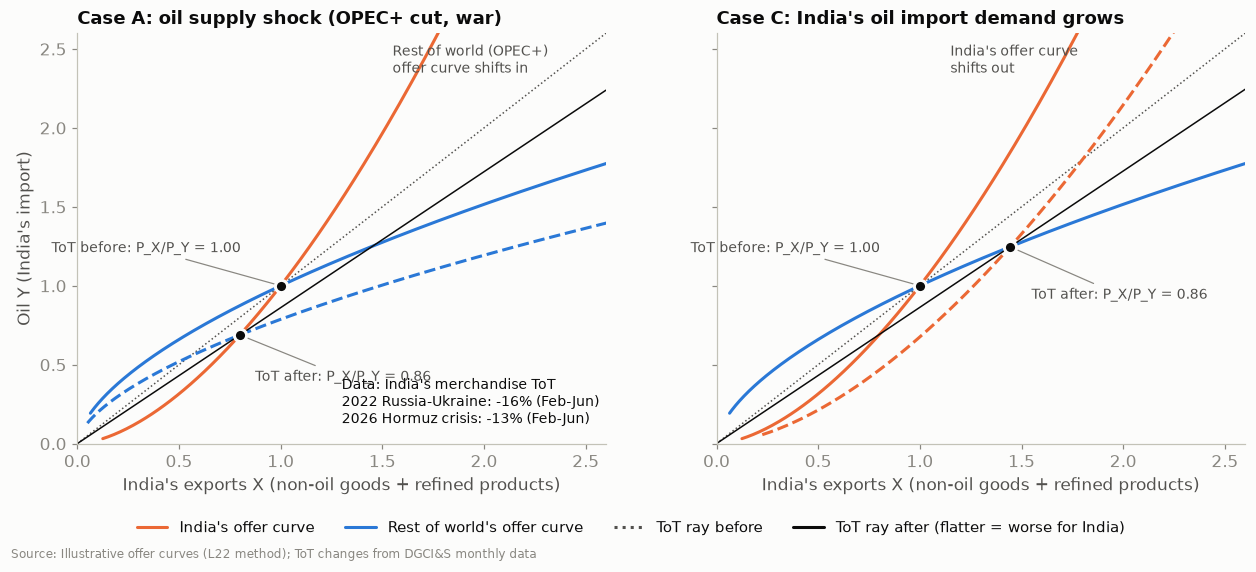

In [2]:
eps, eta = 1.5, 1.5
p = np.linspace(0.25, 3, 400)
def oc_india(k): return k * p**eps, k * p**(1 + eps)          # (X, Y) offered/demanded by India
def oc_world(h): return h * p**(-(1 + eta)), h * p**(-eta)     # (X, Y) demanded/offered by rest of world
def eq(k, h):
    ps = (h / k) ** (1 / (1 + eps + eta)); return ps, k * ps**eps, k * ps**(1 + eps)

drop22 = 100 * (m.loc["2022-06-01", "ntt_b12"] / m.loc["2022-02-01", "ntt_b12"] - 1)
drop26 = 100 * (m.loc["2026-06-01", "ntt_b12"] / m.loc["2026-02-01", "ntt_b12"] - 1)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharey=True)
cases = [("Case A: oil supply shock (OPEC+ cut, war)", dict(k=1.0, h=1.0), dict(k=1.0, h=0.55), "world"),
         ("Case C: India's oil import demand grows", dict(k=1.0, h=1.0), dict(k=1.8, h=1.0), "india")]
for ax, (title, before, after, who) in zip(axes, cases):
    for prm, ls, lab in ((before, "-", "before"), (after, "--", "after")):
        xi, yi = oc_india(prm["k"]); xw, yw = oc_world(prm["h"])
        if who == "world" or lab == "before":
            ax.plot(xw, yw, color=BLUE, ls=ls, lw=2)
        if who == "india" or lab == "before":
            ax.plot(xi, yi, color=ORANGE, ls=ls, lw=2)
        ps, xe, ye = eq(prm["k"], prm["h"])
        xs = np.linspace(0, 2.6, 10)
        ax.plot(xs, ps * xs, color=INK2 if lab == "before" else INK, lw=1, ls=":" if lab == "before" else "-")
        ax.plot([xe], [ye], "o", ms=8, color=INK, mec=SURFACE, mew=2, zorder=5)
        off = (-150, 22) if lab == "before" else ((10, -30) if who == "world" else (14, -34))
        ax.annotate(f"ToT {lab}: P_X/P_Y = {ps:.2f}", (xe, ye), xytext=off, textcoords="offset points", fontsize=9,
                    color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
    ax.set_xlim(0, 2.6); ax.set_ylim(0, 2.6); ax.grid(False)
    ax.set_xlabel("India's exports X (non-oil goods + refined products)")
    ax.set_title(title, fontsize=11.5)
axes[0].set_ylabel("Oil Y (India's import)")
axes[0].text(1.55, 2.35, "Rest of world (OPEC+)\noffer curve shifts in", fontsize=9, color=INK2)
axes[1].text(1.15, 2.35, "India's offer curve\nshifts out", fontsize=9, color=INK2)
axes[0].text(0.5, 0.05, f"Data: India's merchandise ToT\n2022 Russia-Ukraine: {drop22:+.0f}% (Feb-Jun)\n"
             f"2026 Hormuz crisis: {drop26:+.0f}% (Feb-Jun)", transform=axes[0].transAxes, fontsize=9, color=INK)
from matplotlib.lines import Line2D
fig.legend([Line2D([], [], color=ORANGE), Line2D([], [], color=BLUE), Line2D([], [], color=INK2, ls=":"), Line2D([], [], color=INK)],
           ["India's offer curve", "Rest of world's offer curve", "ToT ray before", "ToT ray after (flatter = worse for India)"],
           loc="lower center", ncol=4, bbox_to_anchor=(0.5, 0.025))
fig.tight_layout(rect=(0, 0.09, 1, 1))
save(fig, "fig07_offer_curves_india", "Illustrative offer curves (L22 method); ToT changes from DGCI&S monthly data")
plt.show()

**How to explain it in the viva.**
- **Case A:** a supply cut makes the rest of the world less willing to trade oil. This is L22's tariff case, with the *oil exporter* as the one restricting trade. Its ToT improves, so India's ToT ray rotates down and gets flatter.
- **Case C:** India is a large buyer (3rd-largest oil consumer, 5.4% of world demand, EIA). When India wants more oil, its own offer curve shifts out and its ToT worsens: L22's "demand changes in country A". This is why India is not a pure price-taker (L11), and why we also use oil shocks identified from OPEC announcements and global supply data, which India does not cause.

In [3]:
share = c.loc[2024, "india_share_world_oil_cons"]
print(f"India's share of world oil consumption 2024 (EIA): {share:.1%}; rank 3 after the US and China")
print(c.loc[[1995, 2005, 2015, 2024], ["oilcons_ind_kbd", "oilcons_worl_kbd", "india_share_world_oil_cons"]])

India's share of world oil consumption 2024 (EIA): 5.4%; rank 3 after the US and China
      oilcons_ind_kbd  oilcons_worl_kbd  india_share_world_oil_cons
year                                                               
1995        1,574.000        69,763.500                       0.023
2005        2,465.440        84,678.800                       0.029
2015        3,848.000        95,860.200                       0.040
2024        5,598.890       103,110.000                       0.054


## 2. Revealed comparative advantage in refined petroleum (L08)

Balassa RCA = (India's exports of good j / India's total exports) ÷ (world exports of j / world total exports). RCA > 1 means India has a comparative advantage. Source: UNCTADstat, the source L08 itself cites.

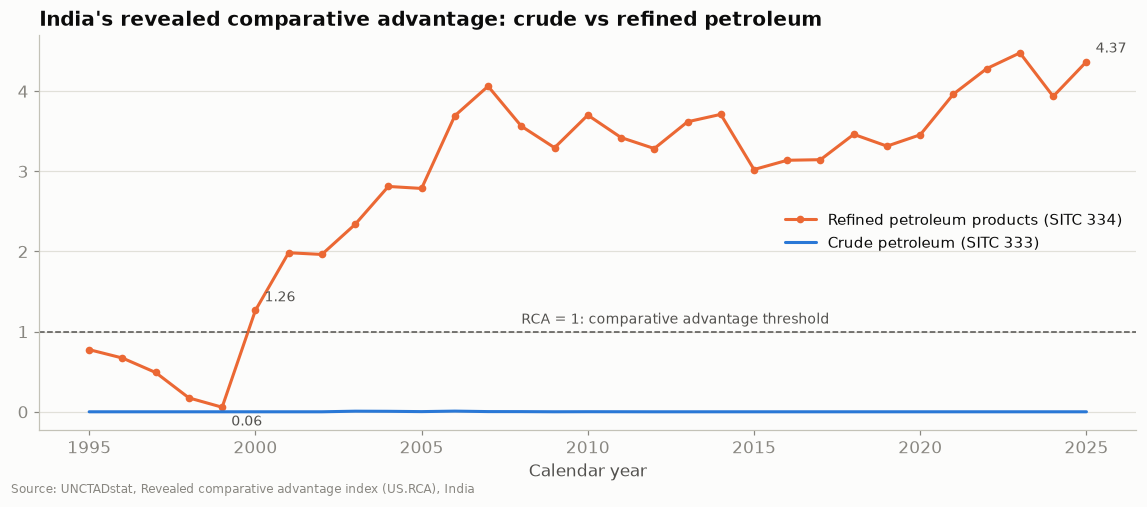

In [4]:
d = c.loc[1995:2025]
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(d.index, d.rca_refined_334, color=ORANGE, marker="o", ms=4, label="Refined petroleum products (SITC 334)")
ax.plot(d.index, d.rca_crude_333.fillna(0), color=BLUE, label="Crude petroleum (SITC 333)")
ax.axhline(1, color=INK2, lw=1, ls="--")
ax.text(2008, 1.1, "RCA = 1: comparative advantage threshold", fontsize=9, color=INK2)
for y in (1999, 2000, 2025):
    ax.annotate(f"{d.loc[y, 'rca_refined_334']:.2f}", (y, d.loc[y, "rca_refined_334"]), xytext=(6, 6 if y != 1999 else -12),
                textcoords="offset points", fontsize=9, color=INK2)
ax.set_title("India's revealed comparative advantage: crude vs refined petroleum")
ax.legend(loc="center right"); ax.set_xlabel("Calendar year")
fig.tight_layout()
save(fig, "fig04_rca_refined_petroleum", "UNCTADstat, Revealed comparative advantage index (US.RCA), India")
plt.show()

**Reading.** India has almost no comparative advantage in crude (RCA ≈ 0; it has little oil, consistent with H-O endowments, L12). Its RCA in refined products jumped from 0.06 (1999) to 1.26 (2000) and is about 4 today.
- This is an **acquired** comparative advantage (L19, Lancaster), built on refining scale economies (L16–L17).
- It puts oil-linked goods into India's *export* basket (s_x > 0), which cuts the net ToT exposure (notebook 01, section 3).

## 3. Grubel–Lloyd index: how "industry" definition changes the picture (L17, L19)

GL = 1 − |X − M| / (X + M), where 0 = pure one-way (inter-industry) trade and 1 = perfectly balanced two-way (intra-industry) trade.
- **Aggregated:** crude (2709) and refined products (2710) treated as one "oil" industry.
- **Disaggregated (HS-4):** the trade-weighted GL of the two separate lines.

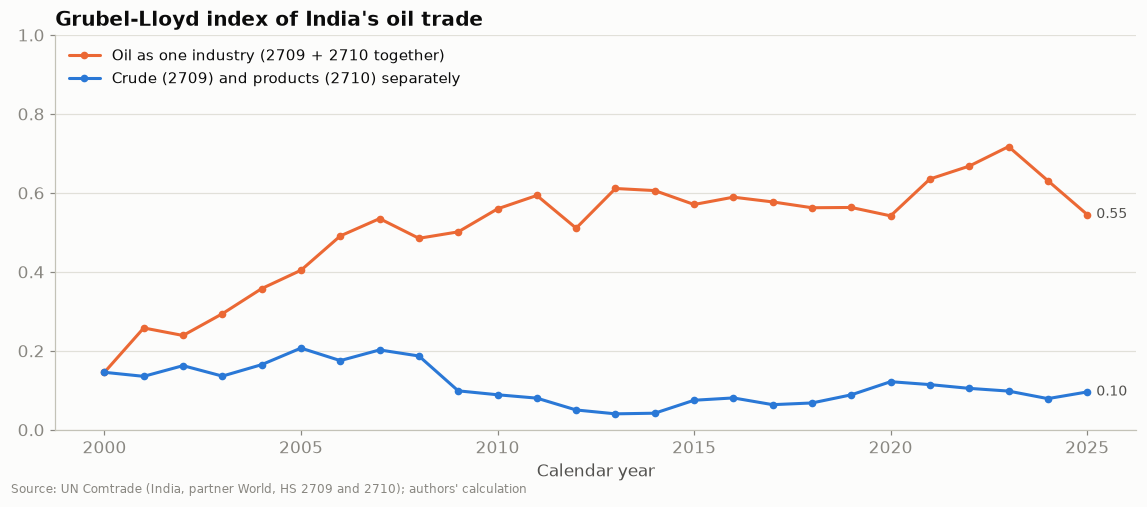

,Crude import unit value (US$/t),Refined export unit value (US$/t),Ratio export/import
year,,,
2005,361.405,462.952,1.281
2015,368.807,520.324,1.411
2022,713.152,996.286,1.397
2024,585.449,721.254,1.232
2025,528.032,672.854,1.274


In [5]:
d = c.loc[2000:2025]
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(d.index, d.gl_oil_hs2_like, color=ORANGE, marker="o", ms=4, label="Oil as one industry (2709 + 2710 together)")
ax.plot(d.index, d.gl_oil_hs4_weighted, color=BLUE, marker="o", ms=4, label="Crude (2709) and products (2710) separately")
ax.set_ylim(0, 1); ax.set_title("Grubel-Lloyd index of India's oil trade")
ax.legend(loc="upper left"); ax.set_xlabel("Calendar year")
for col in ("gl_oil_hs2_like", "gl_oil_hs4_weighted"):
    ax.annotate(f"{d[col].iloc[-1]:.2f}", (d.index[-1], d[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK2)
fig.tight_layout()
save(fig, "fig05_grubel_lloyd_aggregation", "UN Comtrade (India, partner World, HS 2709 and 2710); authors' calculation")
plt.show()
uv = c.loc[[2005, 2015, 2022, 2024, 2025], ["uv_imp_crude_usd_t", "uv_exp_refined_usd_t", "uv_ratio_refined_x_over_crude_m"]]
uv.columns = ["Crude import unit value (US$/t)", "Refined export unit value (US$/t)", "Ratio export/import"]
save_table(uv, "t11_unit_values_vertical_iit", floatfmt=".2f")
uv

**Reading.**
- Aggregated, India's oil trade looks substantially intra-industry (GL about 0.55–0.7). Disaggregated, it is mostly inter-industry (GL about 0.05–0.12). This is L17's warning about broad industry definitions.
- The export unit value of refined products is about 1.2–1.4 times the import unit value of crude, outside the ±15% band of the Abd-el-Rahman/GHM rule (L20). So whatever two-way trade exists is **vertical** (value-adding).

## 4. Partial equilibrium: the crude import market (L21)

India's crude import demand is price-inelastic in the short run. When world supply shifts up, the **price** (and so the import bill) jumps while the **volume** barely moves.

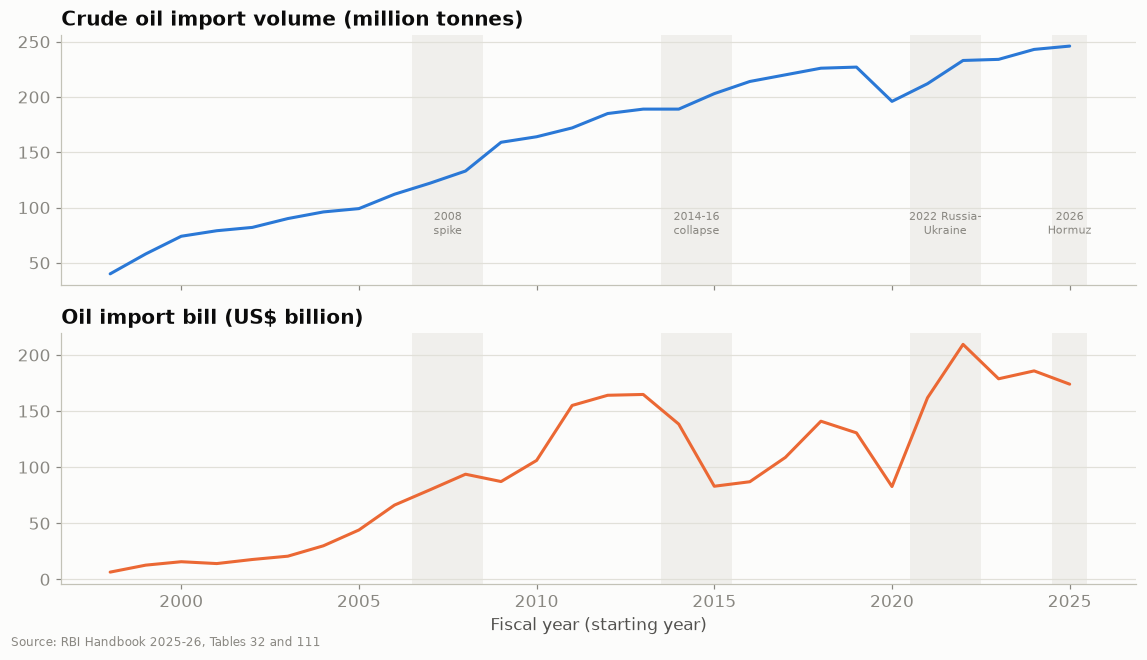

Crude import volume vs oil price (annual log changes, FY1999-2025): elasticity = 0.158 (s.e. 0.094)
Oil import bill vs oil price: corr of log changes = 0.96


In [6]:
d = a.loc[1998:2025]   # RBI Table 32 rows for FY1990-97 are a duplicated block (see validation report)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 6), sharex=True)
ax1.plot(d.index, d.crude_imp_mmt, color=BLUE)
ax1.set_title("Crude oil import volume (million tonnes)")
ax2.plot(d.index, d.m_oil_usdm / 1000, color=ORANGE)
ax2.set_title("Oil import bill (US$ billion)")
for ax in (ax1, ax2):
    shade_episodes(ax, [e for e in EPISODES_FY if e[0] >= 1998], label=(ax is ax1), y=0.3)
ax2.set_xlabel("Fiscal year (starting year)")
fig.tight_layout()
save(fig, "fig06_import_volume_vs_bill", "RBI Handbook 2025-26, Tables 32 and 111")
plt.show()
x = np.log(a.loc[1998:2025, ["crude_imp_mmt", "m_oil_usdm", "oil_avg"]]).diff().dropna()
r = smf.ols("crude_imp_mmt ~ oil_avg", data=x).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
print(f"Crude import volume vs oil price (annual log changes, FY1999-2025): elasticity = {r.params['oil_avg']:.3f} (s.e. {r.bse['oil_avg']:.3f})")
print(f"Oil import bill vs oil price: corr of log changes = {np.corrcoef(x.m_oil_usdm, x.oil_avg)[0,1]:.2f}")

**Reading.** Volume grows smoothly with the economy. The bill tracks the oil price (FY2008-09, FY2011-14, FY2022-23 peaks; FY2015-16 and FY2020-21 troughs). There is no evidence that higher prices cut import volume (see the estimate printed above: not significantly negative; a positive sign reflects growth-driven demand). So the PE burden of a supply shock falls on India as a **price** (ToT) loss rather than a quantity adjustment.